In [ ]:
# Breast Cancer Detection using Breast Cancer Wisconsin (Diagnostic) Dataset.

In [8]:
# Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score,classification_report,ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score,roc_curve, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost
from xgboost import XGBClassifier

In [2]:
# Import Dataset
df=pd.read_csv('breast_cancer.csv')

In [ ]:
            # -------Perform Exploratory Data Analysis-------#

In [3]:
# Shape of the dataset
df.shape

(569, 32)

In [4]:
# Quick look the dataset
df.head(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [27]:
# Check the column name
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
# Perform preprocessing

In [5]:
# Drop unnecessary ID column
df=df.drop('id', axis=1)

In [ ]:
# Perform labelencoding on diagnosis column
encoder=LabelEncoder()
df['diagnosis'] = encoder.fit_transform(df['diagnosis'])

In [10]:
# Check Basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [11]:
# Basic Statistics
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [12]:
# Check any missing value
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

<Axes: >

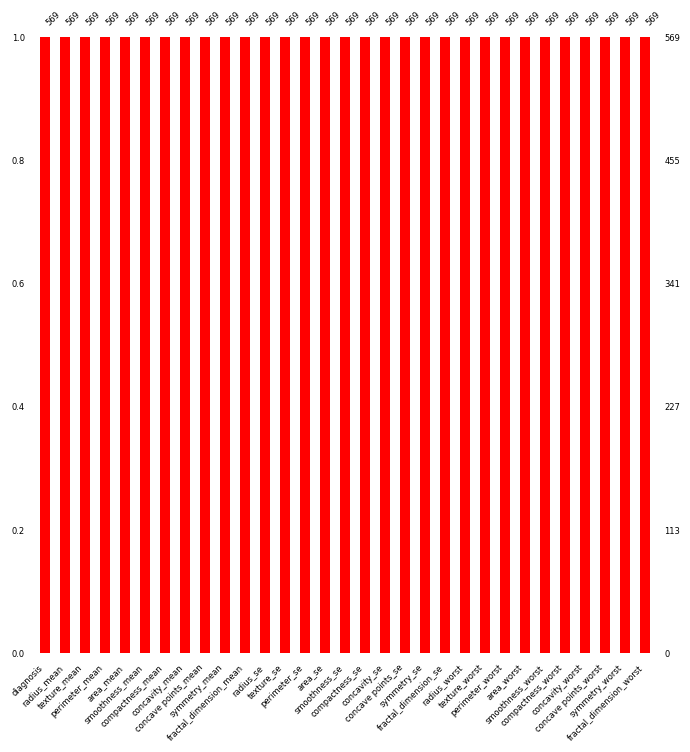

In [13]:
# Use missingo to show missing value
msno.bar(df,
        figsize=(8,8), 
        color='red', 
        fontsize=6)

In [9]:
# Check any duplicated value
df.duplicated().sum()

np.int64(0)

In [14]:
# Check whether data is imbalanced or not
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

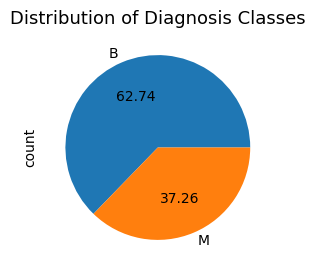

In [7]:
# Draw Pie chart to know the percentage frequency of Diagnosis classes
plt.figure(figsize=(3,3))
df['diagnosis'].value_counts().plot(
    kind='pie', 
    autopct='%.2f',
    labels=['B', 'M']
      )
plt.title('Distribution of Diagnosis Classes', fontsize=13)
plt.show()

In [ ]:
# It is also a balanced data

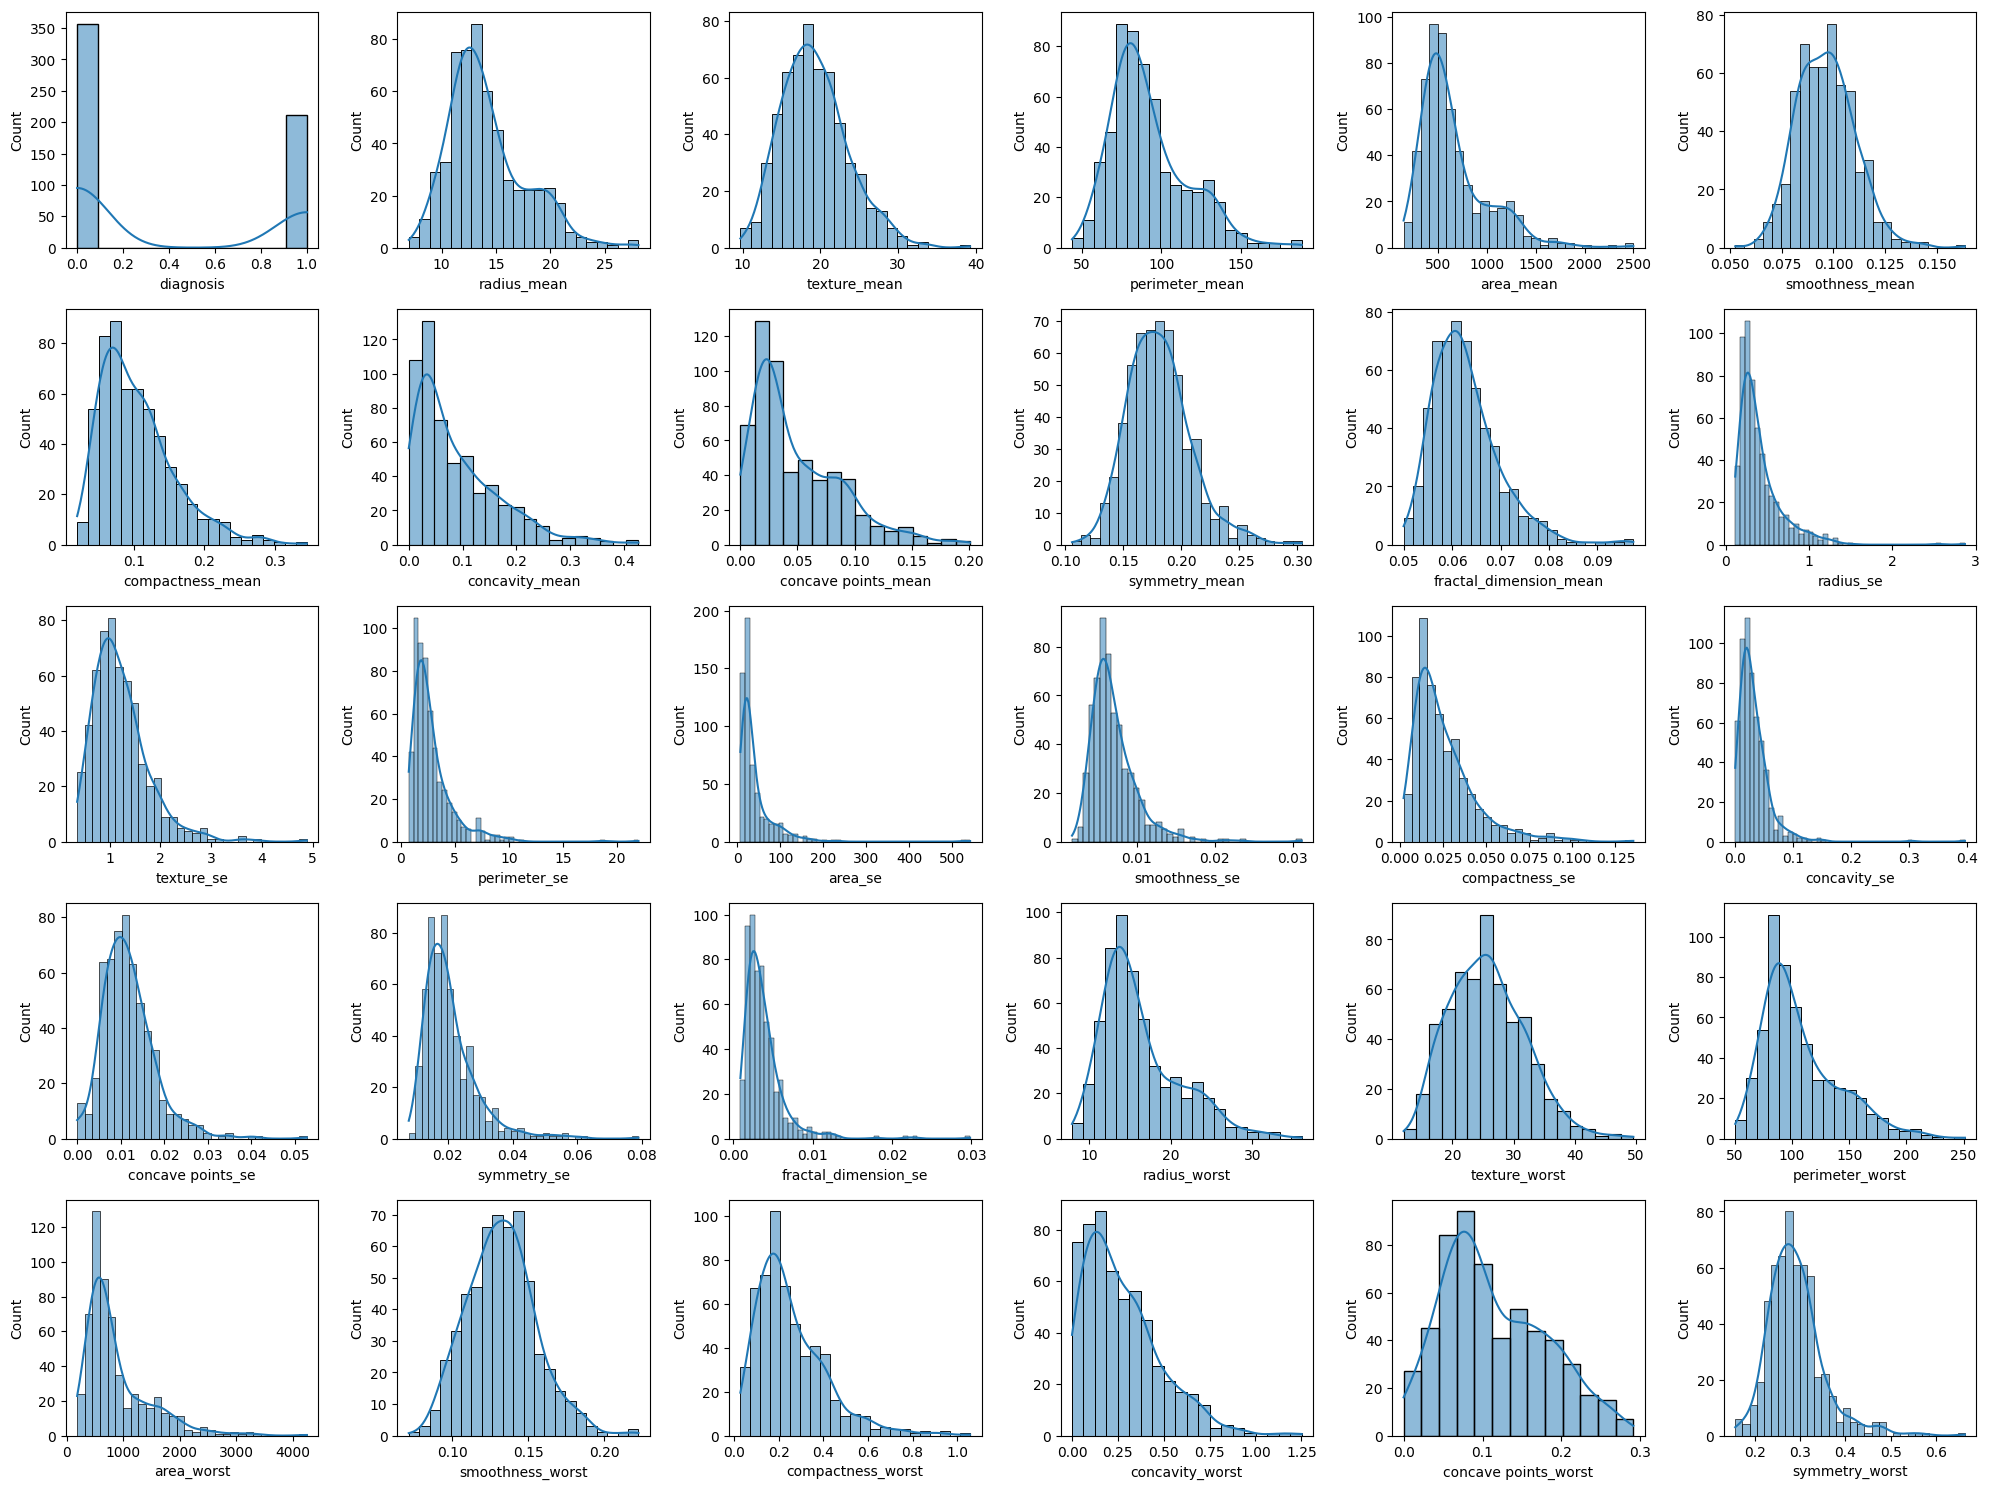

In [34]:
# Show the distribution of independent column
plt.figure(figsize=(20, 15))
plotnumber=1
for column in df:
    if plotnumber<=30:
        ax=plt.subplot(5,6, plotnumber)
        sns.histplot(df[column], kde=True, ax=ax)
        plt.xlabel(column)
    plotnumber+=1
plt.tight_layout()
plt.show()

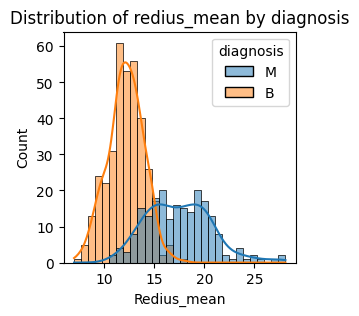

In [ ]:
# radius_mean distribution by diagnosis
plt.figure(figsize=(3,3))
sns.histplot(data=df, 
             x='radius_mean', 
             hue='diagnosis', 
             bins=30, 
             kde=True)
plt.xlabel('Redius_mean')
plt.title('Distribution of redius_mean by diagnosis')
plt.show()

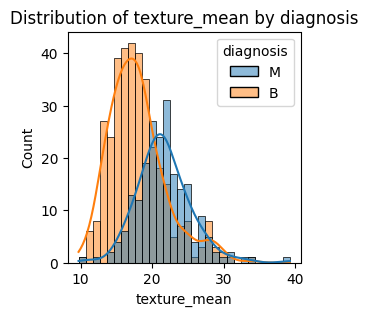

In [ ]:
# texture_mean distribution by diagnosis
plt.figure(figsize=(3,3))
sns.histplot(data=df, 
             x='texture_mean', 
             hue='diagnosis', 
             bins=30, 
             kde=True)
plt.xlabel('texture_mean')
plt.title('Distribution of texture_mean by diagnosis')
plt.show()

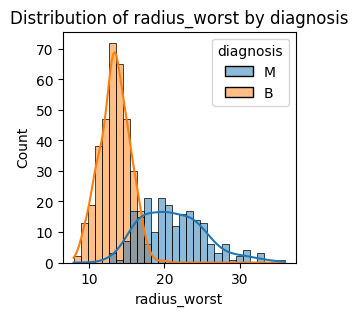

In [ ]:

# radius_worst distribution by diagnosis
plt.figure(figsize=(3,3))
sns.histplot(data=df, 
             x='radius_worst', 
             hue='diagnosis', 
             bins=30, 
             kde=True)
plt.xlabel('radius_worst')
plt.title('Distribution of radius_worst by diagnosis')
plt.show()

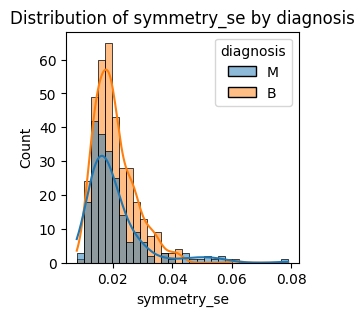

In [ ]:
# symmetry_se distribution by diagnosis
plt.figure(figsize=(3,3))
sns.histplot(data=df, 
             x='symmetry_se', 
             hue='diagnosis', 
             bins=30, 
             kde=True)
plt.xlabel('symmetry_se')
plt.title('Distribution of symmetry_se by diagnosis')
plt.show()

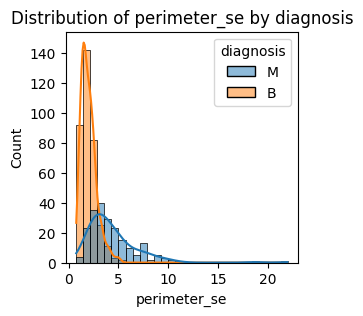

In [ ]:
# perimeter_se distribution by diagnosis
plt.figure(figsize=(3,3))
sns.histplot(data=df, 
             x='perimeter_se', 
             hue='diagnosis', 
             bins=30, 
             kde=True)
plt.xlabel('perimeter_se')
plt.title('Distribution of perimeter_se by diagnosis')
plt.show()

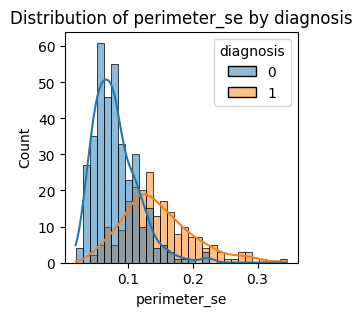

In [14]:
# compactness_mean distribution by diagnosis
plt.figure(figsize=(3,3))
sns.histplot(data=df, 
             x='compactness_mean', 
             hue='diagnosis', 
             bins=30, 
             kde=True)
plt.xlabel('perimeter_se')
plt.title('Distribution of perimeter_se by diagnosis')
plt.show()

In [35]:
# Show the correlation of the column
df.corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


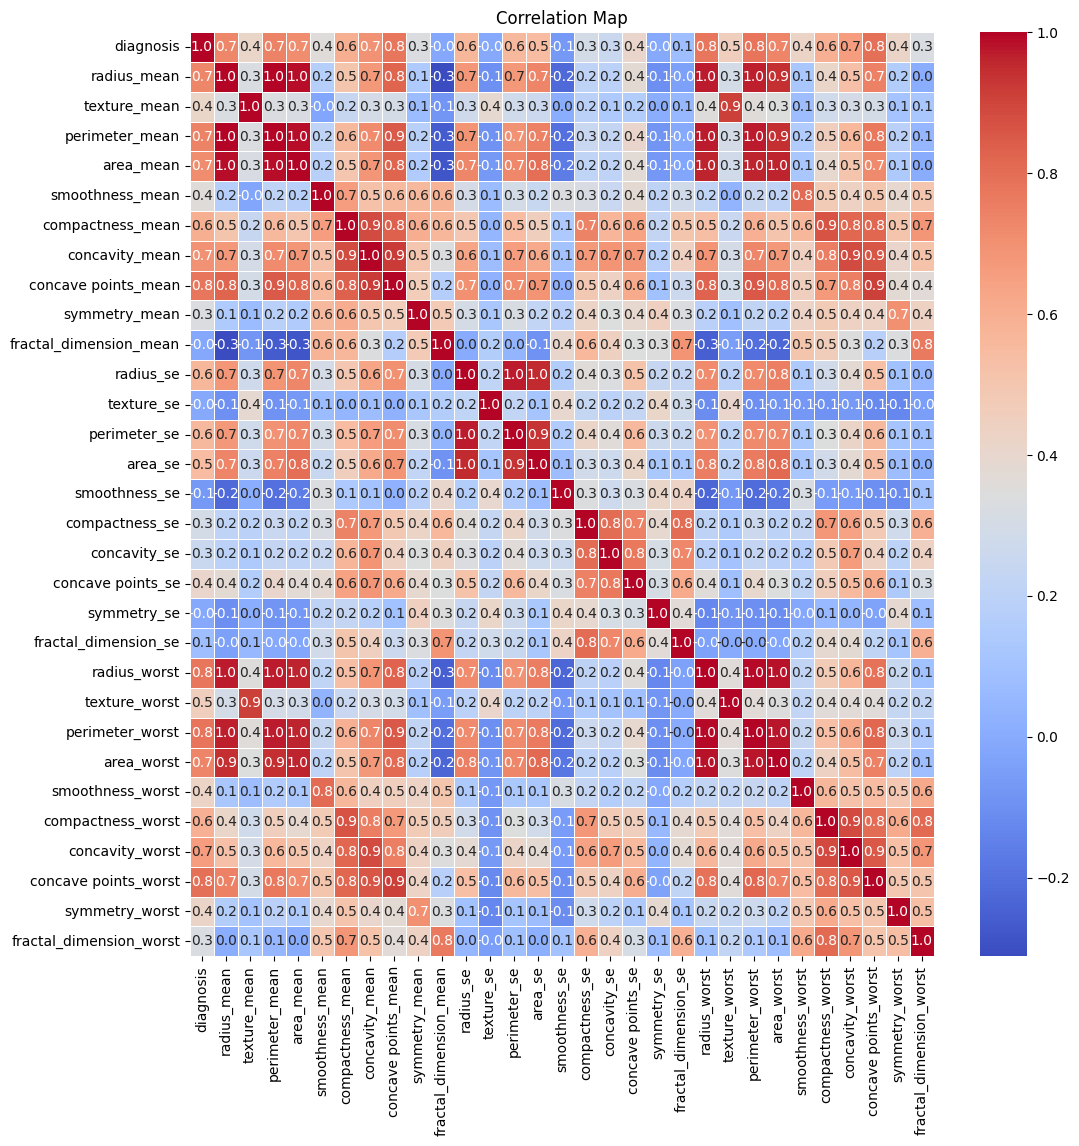

In [10]:
# Make heatmap to show the correlation between different column
numeric_data = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 12))
sns.heatmap(
    numeric_data.corr(),
    annot=True,
    linewidths=0.5, 
    fmt=".1f", 
    cmap="coolwarm")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Correlation Map')
plt.savefig('graph.png')
plt.show()

In [ ]:
# Findings from EDA 
    # There are no missing value
    # There are no duplicated vale
    # It is balanced data
    # Some column show multicolinearity

In [ ]:
            #-------Cleaning the Data------#
# As data has no missing and duplicated value no need to perform cleaning process

In [ ]:
        #---------Feature Engineering------#

In [ ]:
# LabelEncoding is performed on categorical (diagnosis column) data before.

In [ ]:
        #----------Feature Selection-------#

In [16]:
# Remove Highly correlated feature (Multicolinearity)
# Correlation with target
corr=df.corr()['diagnosis'].abs()
important_col=corr[corr>0.2].index
df_filtered=df[important_col].drop('diagnosis', axis=1)
df_filtered

# Feature Selection
# Drop the column with highly correlated
corr_matrix = df_filtered.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
df_final = df_filtered.drop(columns=to_drop)
print(df_final.shape)

(569, 18)


In [17]:
# Now concatenate the diagnosis column with df_final
df_final = df_final.copy()
df_final.loc[:, 'diagnosis'] = df['diagnosis'].values

In [18]:
# Show the shape of the column
df_final.shape

(569, 19)

In [ ]:
        #---------Define input and output feature and split the data-------#

In [19]:
# Extract Independent and Dependent features
X=df_final.drop('diagnosis', axis=1)
y=df_final['diagnosis']

In [20]:
# Split the dataset into tain and testset
X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [ ]:
            # --------Feature Scaling--------#

In [21]:
# Creating Standscaler Object
scaler=StandardScaler()
# Fit scaler on training data
scaler.fit(X_train)
# Transformed training data
X_train_scaled=scaler.transform(X_train)
# Transformed test data
X_test_scaled=scaler.transform(X_test)

In [22]:
# Convert back to DataFrame (helps SHAP & readability)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

In [ ]:
        #----------Train and Evaluate the model--------#

In [ ]:
# 1. Initialize and train the Logistic Regression model

In [ ]:

# Define the Logistic Regression model with chosen hyperparameters
log_r=LogisticRegression(
    max_iter=5000,
    C=0.1,
    solver='liblinear',
    random_state=42)

# Train the model
log_r.fit(X_train, y_train)

# Predict the target value
y_pred_lr=log_r.predict(X_test)

# Evaluate the model accuracy_score
accuracy=accuracy_score(y_test, y_pred_lr)
print(f"Accuracy of the Logistic_Regression model is : {accuracy*100:0.2f}%")

Accuracy of the Logistic_Regression model is : 90.35%


In [ ]:
# 2. Initialize and train the Support Vector Machine Algorithm

In [ ]:
# Find the best Hyperparameter for SVC
# Define the parameter grid
param_grid={
    'gamma':[1, 0.1, 0.01, 0.001],
    'C':[0.1, 1, 10, 100],
    'kernel':['rbf']
}

# Define the svm model
svm=SVC()

# Peform GridsearchCV to find best parameter
grid=GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train the model
grid.fit(X_train, y_train)

# Show the best parameters and best scores
print("Best Parameters:", grid.best_params_)
print("Best Parameters:", grid.best_score_)


Best Parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best Parameters: 0.9384615384615385


In [25]:
# Define the SVM with best Hyperparameters
svm=SVC(
    kernel='rbf',
    gamma=0.01,
    C=100)

# Train the model
svm.fit(X_train, y_train)

# Predic the target value
y_pred_svm=svm.predict(X_test)

# Evaluate the model accuracy_score
accuracy=accuracy_score(y_pred_svm, y_test)
print(f'Accuracy of the SMV model is: {accuracy*100: 0.2f}%')

Accuracy of the SMV model is:  95.61%


In [ ]:
# 3. Initialize and train the KNN algorithm

In [ ]:
# Try to find out best N_neighbours
scores=[]
for i in range (1,16):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred=knn.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

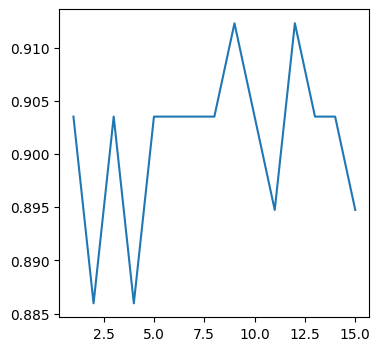

In [27]:
# Draw the plot to visualize the value
plt.figure(figsize=(4,4))
plt.plot(range(1,16), scores)

In [ ]:
# Initialize the model with best n_neighbours

# Define the KNN with n_neighbours
knn=KNeighborsClassifier(n_neighbors=8, n_jobs=-1)

# Train the model
knn.fit(X_train, y_train)

# Predict the target value
y_pred_knn=knn.predict(X_test)

# Findout the accuracy
accuracy=accuracy_score(y_pred_knn, y_test)
print(f"The accuracy of the KNN model: {accuracy*100:0.2f}%")

The accuracy of the KNN model: 90.35%


In [ ]:
# 4. Initialize and train the DecisionTree algorithm

In [32]:
# Find the best parameter of DecisionTree algorithm using GridsearchCV

# Create parametrs
param_dist={
    'criterion': ['gini', 'entropy'],
    'max_depth': [1,2,3,4,5,6,7,None],
    'min_samples_split': [20, 30, 40, 50, 100]
}

# Create DecisionTree classification object
clf=DecisionTreeClassifier()
# Create GridsearchCV object
grid=GridSearchCV(
    estimator=clf,
    param_grid=param_dist,
    cv=10
)
# Train the model and evaluate it using GridSearchCv
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, ...], 'min_samples_split': [20, 30, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [34]:
# Show the best parameter and score
grid.best_params_

{'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 20}

In [36]:
# Training the DecisionTreeClassifier with best hyperparameter
clf=DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    min_samples_split=20
    )
clf.fit(X_train, y_train)
y_pred=clf.predict(X_test)

# Evaluate the model
accuracy=accuracy_score(y_test, y_pred)
print(f"The accuracy of the KNN model: {accuracy*100:0.2f}%")

The accuracy of the KNN model: 92.98%
